 # Pointwise Custom-DRAG Analysis



 This notebook separates the expensive pulse construction from the subsequent

 propagation and plotting stages. Once a numerical pulse has been obtained, the

 analysis and visualization cells can be rerun without repeating the pointwise

 optimization.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qutip import sesolve
from scipy.interpolate import CubicSpline
from scipy.linalg import expm
from tqdm.auto import tqdm

from custom_drag_optimizer_class import CustomDRAGConfig, CustomDRAGOptimizer
from FAPT import Heff_Floquet_total_matrix_summed, W_Floquet_elements_fast
from pulse_optimization import infid_population
from utils import Simulation

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "lines.linewidth": 1.6,
})


 ## 1. Configuration



 The configuration fixes the perturbative truncation, pulse family, gate time,

 and numerical resolution. Enabling the second harmonic introduces two

 additional quadratures which are used to suppress the effective coupling

 $H_{02}$.

In [2]:
tg = 25
config = CustomDRAGConfig(
    tg=tg,
    sigma_r=0.1,
    pulse_type="tanh",       # "gauss" or "tanh"
    drag_order=5,
    rH=2,
    rW=1,
    use_second_harmonic=True,
    run_drag_target_simulation=True,
    N_t=2000,
    max_nfev=150,
    robust_pointwise=False,
    robust_debug=False,
    robust_multistart=10,
    robust_global_maxiter=50,
)

s = Simulation()
result = CustomDRAGOptimizer(s, config)

checkpoint_dir = Path("operational_res/custom_drag")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / (
    f"pointwise_{config.pulse_type}_tg{config.tg:g}_"
    f"Nt{config.N_t}_second{int(config.use_second_harmonic)}.npz"
)


Initial resonance frequency: wd0 = 4.43804329
DRAG variant:                custom
Base pulse:                  tanh
Second harmonic / H02 cancel: True


In [3]:
import os
import pickle
from pathlib import Path

def get_save_filename(result_optimizer) -> Path:
    """Generiert einen eindeutigen Dateipfad basierend auf allen wichtigen Parametern."""
    c = result_optimizer.c
    
    # Verzeichnis erstellen, falls es nicht existiert
    out_dir = Path("operational_res/numerical_pulse_shaping")
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # Alle relevanten System- und Optimierungsparameter im Dateinamen zusammenfassen
    filename = (
        f"drag_{c.drag_variant}_"
        f"{c.pulse_type}_"
        f"tg{c.tg:.1f}_"
        f"order{c.drag_order}_"
        f"rH{c.rH}_rW{c.rW}_"
        f"Nt{c.N_t}_"
        f"2ndHarm{c.use_second_harmonic}_"
        f"sig{c.sigma_r:.3f}_"
        f"c02w{c.c02_weight:.2f}"
        f".pkl"
    )
    
    return out_dir / filename

# --- DATEIPFAD BESTIMMEN ---
save_path = get_save_filename(result)

# --- CACHING & LADE-LOGIK ---
if save_path.exists():
    print(f"\n[CACHE HIT] Gefundene Datei geladen: {save_path}")
    with open(save_path, "rb") as f:
        result = pickle.load(f)
else:
    print(f"\n[CACHE MISS] Führe Berechnung durch und speichere unter: {save_path}")
    
    # 1. Vorbereiten und Optimieren (falls noch nicht vor 'optimize_pointwise' geschehen)
    result.prepare_base_target()
    result.optimize_pointwise()
    
    # 2. Vollständiges Objekt auf der Festplatte sichern
    with open(save_path, "wb") as f:
        pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print(f"Erfolgreich gespeichert unter {save_path}")


[CACHE HIT] Gefundene Datei geladen: operational_res/numerical_pulse_shaping/drag_custom_tanh_tg25.0_order5_rH2_rW1_Nt2000_2ndHarmTrue_sig0.100_c02w1.00.pkl


 ## 4. Save the pointwise result



 The optimized controls, effective Hamiltonians, targets, and derivative data

 are stored independently of all later propagation and plotting choices.

In [4]:
pointwise_fields = (
    "f0", "base_solutions", "ep0", "ep0_dot",
    "solutions", "control_derivatives",
    "Delta_values", "dDelta_values", "lambda_values",
    "targets", "H_eff_values",
    "optimization_residuals", "total_residuals",
    "core_scales", "H01_scale", "H02_scale",
)

np.savez_compressed(
    checkpoint_path,
    **{name: getattr(result, name) for name in pointwise_fields},
)
print(f"Saved pointwise result to {checkpoint_path}")


Saved pointwise result to operational_res/custom_drag/pointwise_tanh_tg25_Nt2000_second1.npz


 ## 5. Restore a previous pointwise result



 After restarting the kernel, execute the import and configuration cells, then

 this cell instead of the base-pulse and pointwise-optimization cells. The

 continuous control splines and diagnostics are reconstructed automatically.

In [5]:
def restore_pointwise_result(result, path):
    data = np.load(path, allow_pickle=False)
    for name in data.files:
        value = data[name]
        setattr(result, name, value.item() if value.ndim == 0 else value)

    c = result.c
    result.wd_values, result.Ar_values, result.Ai_values = result.solutions[:, :3].T
    result.dwd_values, result.dAr_values, result.dAi_values = result.control_derivatives[:, :3].T

    if c.use_second_harmonic:
        result.Ar2_values, result.Ai2_values = result.solutions[:, 3:5].T
        result.dAr2_values, result.dAi2_values = result.control_derivatives[:, 3:5].T
    else:
        result.Ar2_values = result.Ai2_values = np.zeros(c.N_t)
        result.dAr2_values = result.dAi2_values = np.zeros(c.N_t)

    for name in ("wd", "Ar", "Ai", "Ar2", "Ai2"):
        setattr(result, f"{name}_func", CubicSpline(result.tlist, getattr(result, f"{name}_values")))
    for name in ("dwd", "dAr", "dAi", "dAr2", "dAi2"):
        setattr(result, f"{name}_func", CubicSpline(result.tlist, getattr(result, f"{name}_values")))

    result.compute_diagnostics()
    return result


# Uncomment this line when loading an existing checkpoint.
# result = restore_pointwise_result(result, checkpoint_path)


 ## 6. Pulse and target-matching diagnostics



 These cells only use stored pointwise data. They can be modified and rerun

 without repeating the optimization.

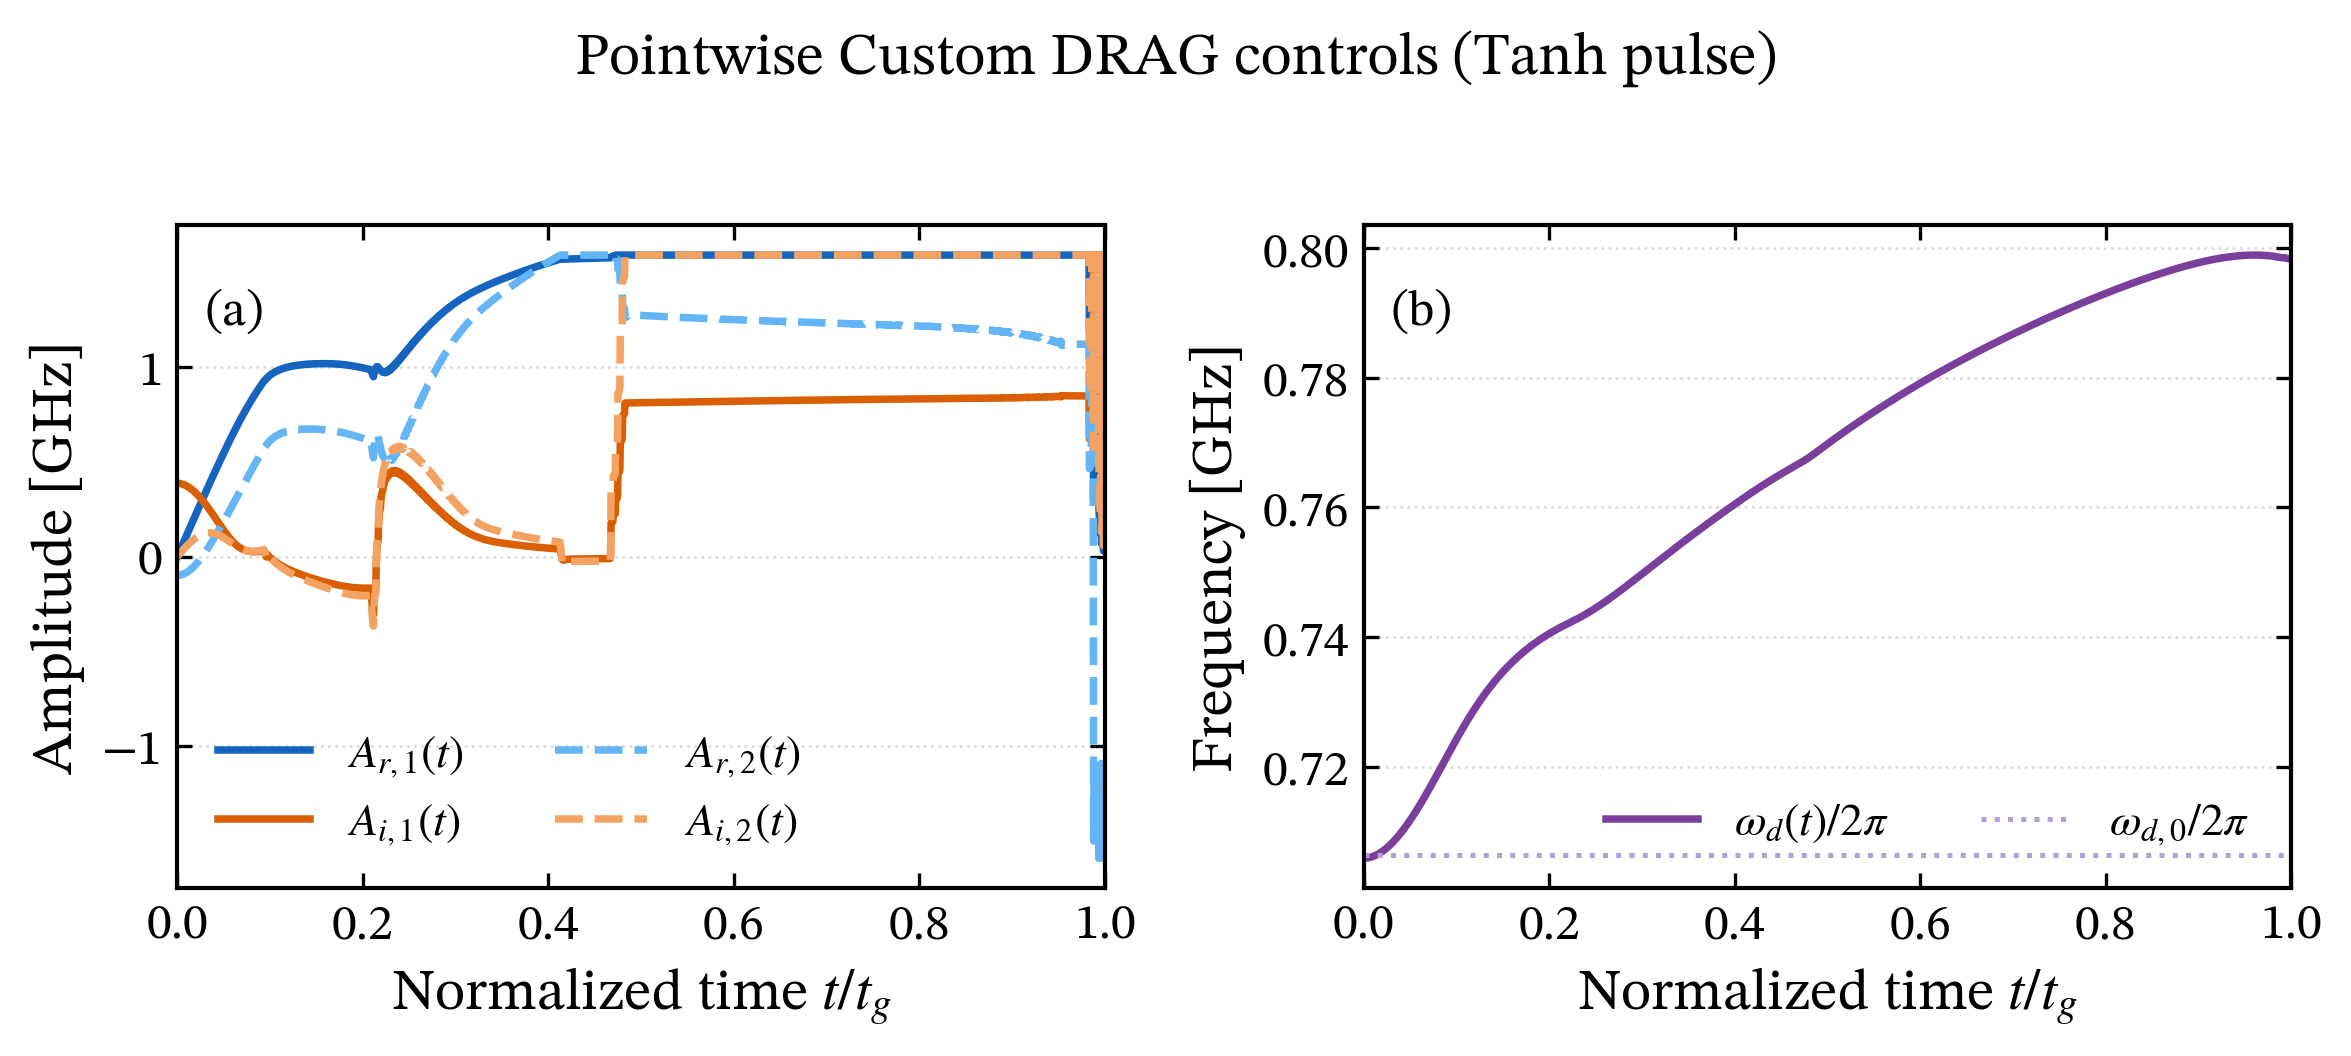

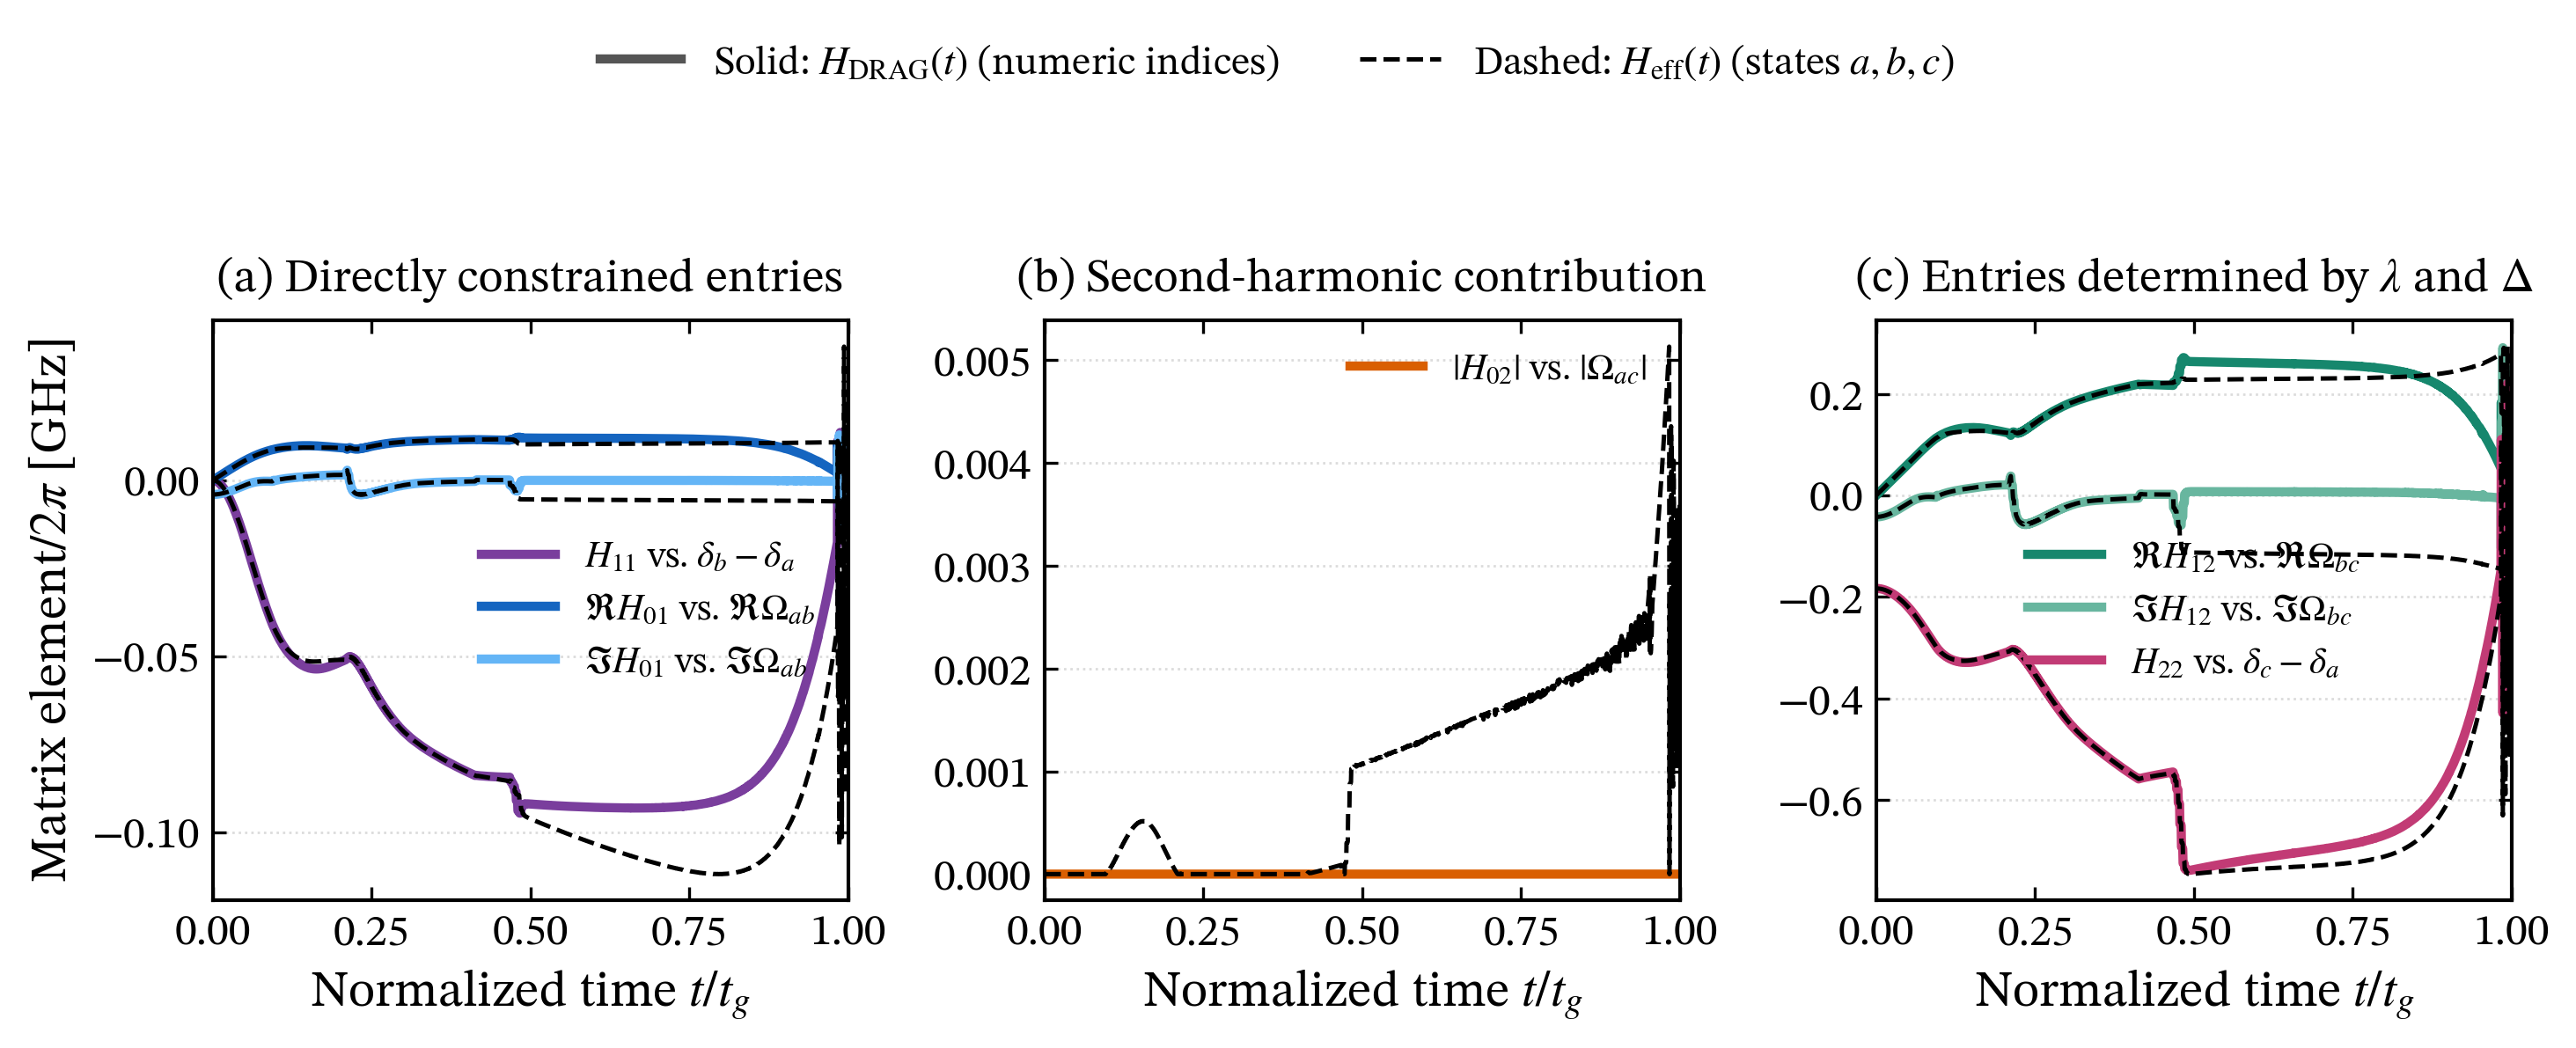

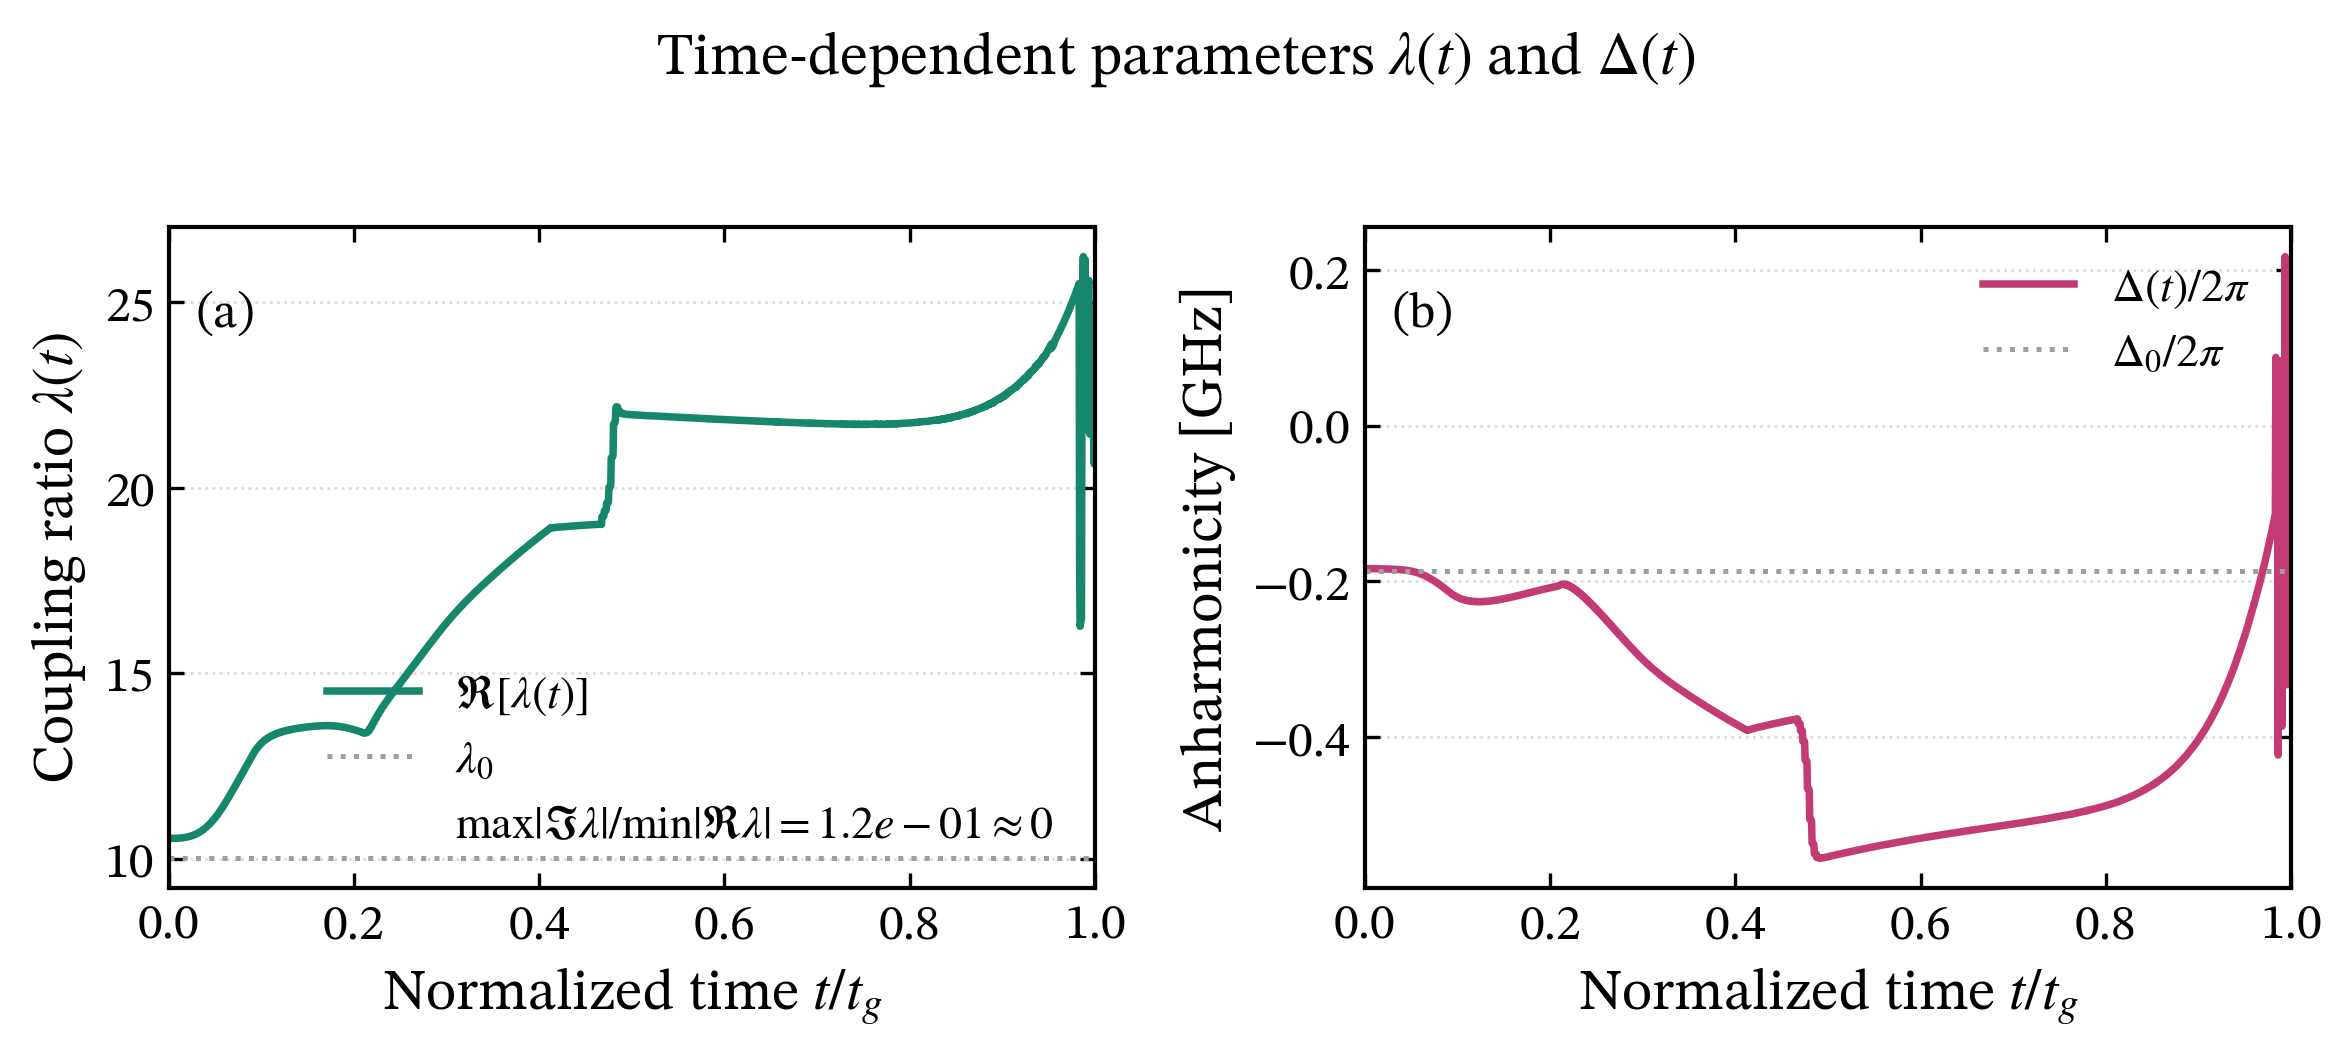

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


RAD_NS_TO_GHZ = 1.0 / (2.0 * np.pi)


def setup_chapter5_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIX Two Text", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "axes.linewidth": 1.0,
        "lines.linewidth": 1.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "savefig.dpi": 300,
    })


def finish_figure(fig, save_path=None, rect=None):
    fig.tight_layout(rect=rect)

    if save_path:
        path = Path(save_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches="tight")


def plot_pulse_shapes(optimizer, save_path=None):
    setup_chapter5_style()

    x = optimizer.tlist / optimizer.c.tg
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.4), sharex=True, dpi=300)

    colors = {
        "Ar1": "#1565C0",
        "Ar2": "#64B5F6",
        "Ai1": "#D95F02",
        "Ai2": "#F4A261",
        "wd": "#7A3E9D",
        "wd0": "#B39DDB",
    }

    axes[0].plot(x, optimizer.Ar_values * RAD_NS_TO_GHZ, color=colors["Ar1"], label=r"$A_{r,1}(t)$")
    axes[0].plot(x, optimizer.Ai_values * RAD_NS_TO_GHZ, color=colors["Ai1"], label=r"$A_{i,1}(t)$")

    if optimizer.c.use_second_harmonic:
        axes[0].plot(x, optimizer.Ar2_values * RAD_NS_TO_GHZ, "--", color=colors["Ar2"], label=r"$A_{r,2}(t)$")
        axes[0].plot(x, optimizer.Ai2_values * RAD_NS_TO_GHZ, "--", color=colors["Ai2"], label=r"$A_{i,2}(t)$")

    axes[0].set_xlabel(r"Normalized time $t/t_g$")
    axes[0].set_ylabel(r"Amplitude [GHz]")

    wd_ghz = optimizer.wd_values * RAD_NS_TO_GHZ
    wd0_ghz = optimizer.wd0 * RAD_NS_TO_GHZ

    axes[1].plot(x, wd_ghz, color=colors["wd"], label=r"$\omega_d(t)/2\pi$")
    axes[1].axhline(wd0_ghz, color=colors["wd0"], linestyle=":", linewidth=1.2, label=r"$\omega_{d,0}/2\pi$")
    axes[1].set_xlabel(r"Normalized time $t/t_g$")
    axes[1].set_ylabel(r"Frequency [GHz]")

    for label, ax in zip(("(a)", "(b)"), axes):
        ax.text(0.03, 0.85, label, transform=ax.transAxes, fontweight="bold")
        ax.set_xlim(0.0, 1.0)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.65, alpha=0.45)
        ax.legend(loc="best", frameon=False, ncol=2)

    fig.suptitle(
        rf"Pointwise {optimizer.c.drag_variant.capitalize()} DRAG controls "
        rf"({optimizer.c.pulse_type.capitalize()} pulse)",
        y=1.03,
    )

    finish_figure(fig, save_path)
    return fig, axes


def build_drag_hamiltonian(optimizer):
    H_eff = np.asarray(optimizer.H_eff_values, dtype=complex)
    H_drag = np.zeros_like(H_eff)

    H_bb = np.asarray(optimizer.targets[:, 0], dtype=float)
    H_ab = optimizer.targets[:, 1] + 1j * optimizer.targets[:, 2]
    H_bc = optimizer.lambda_values * H_ab
    H_cc = 2.0 * H_bb + optimizer.Delta_values

    H_drag[:, 0, 1] = H_ab
    H_drag[:, 1, 0] = np.conjugate(H_ab)
    H_drag[:, 1, 1] = H_bb
    H_drag[:, 1, 2] = H_bc
    H_drag[:, 2, 1] = np.conjugate(H_bc)
    H_drag[:, 2, 2] = H_cc

    return H_drag


def plot_hamiltonian_comparison(optimizer, save_path=None):
    setup_chapter5_style()

    x = optimizer.tlist / optimizer.c.tg
    H_eff = np.asarray(optimizer.H_eff_values, dtype=complex) * RAD_NS_TO_GHZ
    H_drag = build_drag_hamiltonian(optimizer) * RAD_NS_TO_GHZ

    groups = (
        (
            (
                (H_drag[:, 1, 1].real, H_eff[:, 1, 1].real, r"$H_{11}$", r"$\delta_b - \delta_a$", "#7A3E9D"),
                (H_drag[:, 0, 1].real, H_eff[:, 0, 1].real, r"$\Re H_{01}$", r"$\Re\Omega_{ab}$", "#1565C0"),
                (H_drag[:, 0, 1].imag, H_eff[:, 0, 1].imag, r"$\Im H_{01}$", r"$\Im\Omega_{ab}$", "#64B5F6"),
            ),
            "(a) Directly constrained entries",
        ),
        (
            (
                # Hier wird nun direkt der Betrag dargestellt
                (np.abs(H_drag[:, 0, 2]), np.abs(H_eff[:, 0, 2]), r"$|H_{02}|$", r"$|\Omega_{ac}|$", "#D95F02"),
            ),
            "(b) Second-harmonic contribution",
        ),
        (
            (
                (H_drag[:, 1, 2].real, H_eff[:, 1, 2].real, r"$\Re H_{12}$", r"$\Re\Omega_{bc}$", "#16876D"),
                (H_drag[:, 1, 2].imag, H_eff[:, 1, 2].imag, r"$\Im H_{12}$", r"$\Im\Omega_{bc}$", "#68B69F"),
                (H_drag[:, 2, 2].real, H_eff[:, 2, 2].real, r"$H_{22}$", r"$\delta_c - \delta_a$", "#C23B75"),
            ),
            r"(c) Entries determined by $\lambda$ and $\Delta$",
        ),
    )

    fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.8), sharex=True, dpi=300)

    for ax, (entries, title) in zip(axes, groups):
        for drag_values, eff_values, drag_label, eff_label, color in entries:
            ax.plot(x, drag_values, color=color, linewidth=2.5, label=rf"{drag_label} vs. {eff_label}", zorder=2)
            ax.plot(x, eff_values, color="black", linestyle="--", linewidth=1.2, zorder=5)

        ax.set_title(title, pad=8)
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel(r"Normalized time $t/t_g$")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.65, alpha=0.45)
        ax.legend(loc="best", frameon=False, fontsize=10)

    axes[0].set_ylabel(r"Matrix element$/2\pi$ [GHz]")

    # Globale Legende oben zur Erklärung des Linienstils
    style_handles = (
        Line2D([0], [0], color="#555555", linewidth=2.5, label=r"Solid: $H_{\mathrm{DRAG}}(t)$ (numeric indices)"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.2, label=r"Dashed: $H_{\mathrm{eff}}(t)$ (states $a,b,c$)"),
    )

    fig.legend(
        handles=style_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        frameon=False,
        ncol=2,
        columnspacing=2.0,
    )

    finish_figure(fig, save_path, rect=(0.0, 0.0, 1.0, 0.86))
    return fig, axes, H_drag, H_eff


def plot_lambda_delta_variation(optimizer, save_path=None):
    setup_chapter5_style()

    x = optimizer.tlist / optimizer.c.tg
    lambda_ref = complex(optimizer.c.rrr)
    Delta_ref = float(optimizer.c.Delta)

    lambda_values = np.asarray(optimizer.lambda_values, dtype=complex)
    Delta_ghz = np.asarray(optimizer.Delta_values, dtype=float) * RAD_NS_TO_GHZ
    Delta_ref_ghz = Delta_ref * RAD_NS_TO_GHZ

    max_imag = np.max(np.abs(lambda_values.imag))
    min_real = np.min(np.abs(lambda_values.real))
    ratio = max_imag / min_real if min_real > 0.0 else 0.0

    if ratio < 1e-12:
        imag_label = r"$\max|\Im\lambda|/\min|\Re\lambda|\approx 0$"
    else:
        imag_label = rf"$\max|\Im\lambda|/\min|\Re\lambda|={ratio:.1e}\approx 0$"

    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.4), sharex=True, dpi=300)

    axes[0].plot(x, lambda_values.real, color="#16876D", label=r"$\Re[\lambda(t)]$")
    axes[0].axhline(lambda_ref.real, color="#9E9E9E", linestyle=":", linewidth=1.2, label=r"$\lambda_0$")
    axes[0].plot([], [], color="none", label=imag_label)
    axes[0].set_xlabel(r"Normalized time $t/t_g$")
    axes[0].set_ylabel(r"Coupling ratio $\lambda(t)$")

    axes[1].plot(x, Delta_ghz, color="#C23B75", label=r"$\Delta(t)/2\pi$")
    axes[1].axhline(Delta_ref_ghz, color="#9E9E9E", linestyle=":", linewidth=1.2, label=r"$\Delta_0/2\pi$")
    axes[1].set_xlabel(r"Normalized time $t/t_g$")
    axes[1].set_ylabel(r"Anharmonicity [GHz]")

    for label, ax in zip(("(a)", "(b)"), axes):
        ax.text(0.03, 0.85, label, transform=ax.transAxes, fontweight="bold")
        ax.set_xlim(0.0, 1.0)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.65, alpha=0.45)
        ax.legend(loc="best", frameon=False)

    fig.suptitle(r"Time-dependent parameters $\lambda(t)$ and $\Delta(t)$", y=1.03)

    finish_figure(fig, save_path)
    return fig, axes


# Aufrufe
fig_pulse, axes_pulse = plot_pulse_shapes(
    result,
    save_path=f"Figure/5/pointwise_drag_controls_tg{tg}.pdf",
)

fig_comparison, axes_comparison, H_drag, H_eff = plot_hamiltonian_comparison(
    result,
    save_path=f"Figure/5/pointwise_shift_matrix_tg{tg}.pdf",
)

fig_parameters, axes_parameters = plot_lambda_delta_variation(
    result,
    save_path=f"Figure/5/lambda_delta_variation_tg{tg}.pdf",
)

plt.show()

 ## 7. Propagation of the idealized DRAG target



 This propagation tests the generated three-level target independently of the

 Floquet realization. The result provides a useful reference for separating an

 imperfect target from an imperfect mapping of the physical controls.

In [7]:
# result.simulate_drag_target()


In [8]:
# Replot the stored target dynamics without repeating the propagation.
# result.plot_drag_dynamics()
# plt.show()


 ## 8. Full Floquet reconstruction



 The cached effective Hamiltonian is propagated as a reference. In parallel,

 $H_{\mathrm{eff}}(t)$ is recalculated explicitly from the continuous pulse and

 its spline derivatives. The resulting propagator is mapped back with

 $M(t)U_{\mathrm{eff}}(t)M^{-1}(0)$, normalized in the full Hilbert space, and

 only then projected onto the resonant subspace.

In [9]:
def compute_full_floquet(result, full_rH=2, full_rW=2, include_geometric=True, include_g_corr=True, include_micromotion=True):
    c, s = result.c, result.s
    d_res, D = len(s.resonances), len(s.E_array)
    res_indices, kref = list(s.resonances), min(s.resonances)
    splines = (
        result.wd_func, result.Ar_func, result.Ai_func,
        result.Ar2_func, result.Ai2_func,
    )[:result.n_controls]

    def floquet_data(t, compute_heff=True):
        controls = np.array([float(f(t)) for f in splines])
        derivatives = np.array([float(f(t, 1)) for f in splines])
        wd, Ar1, Ai1, Ar2, Ai2 = result.unpack_controls(controls)
        dwd, dAr1, dAi1, dAr2, dAi2 = result.unpack_controls(derivatives)
        A1, dA1 = Ar1 + 1j * Ai1, dAr1 + 1j * dAi1

        if c.use_second_harmonic:
            A = np.array([A1, Ar2 + 1j * Ai2])
            dA = np.array([dA1, dAr2 + 1j * dAi2])
            V = np.array([s.V1_dressed_array, s.V1_dressed_array])
        else:
            A, dA, V = A1, dA1, s.V1_dressed_array

        W = W_Floquet_elements_fast(
            full_rW, wd, s.resonances, s.E_array, V,
            A=A, V0=None, analytics=False, verbose=False,
        )
        if not compute_heff:
            return wd, W, None

        H = Heff_Floquet_total_matrix_summed(
            full_rH, wd, A, s.resonances, s.E_array, V,
            V0=None, ref_state=getattr(s, "ref_state", None),
            dwd=dwd, dA=dA, t=t, analytics=False, rW=full_rW,
            include_geometric=include_geometric, include_micromotion=include_micromotion,
            include_g_correction=include_g_corr, W=W, verbose=False,
        )
        return wd, W, np.asarray(H, dtype=complex)

    def frame_map(wd, W, t):
        M = np.zeros((D, d_res), dtype=complex)
        for r in range(full_rW + 1):
            for l in range(D):
                for column, state in enumerate(s.resonances):
                    for p, (coefficient, _, _) in W[r, l, state].items():
                        M[l, column] += np.exp(
                            -1j * (s.E_array[kref] + p * wd) * t
                        ) * coefficient
        return M

    def project(U_eff, M, M_inv_0):
        columns = (M @ U_eff @ M_inv_0)[:, res_indices]
        norms = np.linalg.norm(columns, axis=0)
        if np.any(norms < 1e-14):
            raise ValueError(f"Floquet columns with vanishing norm: {norms}")
        return (columns / norms[np.newaxis, :])[res_indices, :]

    wd0, W0, _ = floquet_data(result.tlist[0], compute_heff=False)
    M_inv_0 = np.zeros((d_res, D), dtype=complex)
    for r in range(full_rW + 1):
        for l in range(D):
            for row, state in enumerate(s.resonances):
                for _, (coefficient, _, _) in W0[r, l, state].items():
                    M_inv_0[row, l] += np.conjugate(coefficient)

    H_cached = CubicSpline(result.tlist, result.H_eff_values, axis=0)
    shape = (len(result.tlist), d_res, d_res)
    U_cached_values = np.empty(shape, dtype=complex)
    U_explicit_values = np.empty(shape, dtype=complex)
    U_floquet_values = np.empty(shape, dtype=complex)
    U_cached = U_explicit = np.eye(d_res, dtype=complex)
    U_cached_values[0] = U_cached
    U_explicit_values[0] = U_explicit
    U_floquet_values[0] = project(U_explicit, frame_map(wd0, W0, 0.0), M_inv_0)

    for k in tqdm(range(len(result.tlist) - 1), desc="Full Floquet propagation"):
        t0, t1 = result.tlist[k:k + 2]
        t_mid, dt = 0.5 * (t0 + t1), t1 - t0
        U_cached = expm(-1j * H_cached(t_mid) * dt) @ U_cached
        _, _, H_explicit = floquet_data(t_mid)
        U_explicit = expm(-1j * H_explicit * dt) @ U_explicit
        wd, W, _ = floquet_data(t1, compute_heff=False)

        U_cached_values[k + 1] = U_cached
        U_explicit_values[k + 1] = U_explicit
        U_floquet_values[k + 1] = project(
            U_explicit, frame_map(wd, W, t1), M_inv_0
        )

    output = {
        "U_cached_values": U_cached_values,
        "U_explicit_values": U_explicit_values,
        "U_floquet_values": U_floquet_values,
        "I_cached": infid_population(U_cached_values[-1]),
        "I_explicit": infid_population(U_explicit_values[-1]),
        "I_floquet": infid_population(U_floquet_values[-1]),
    }
    result.floquet_result = output
    return output


floquet_result = compute_full_floquet(result, full_rH=2, full_rW=1,
                                      include_micromotion=True, include_g_corr=False, include_geometric=False)
print(f"Cached effective-space infidelity:   {floquet_result['I_cached']:.3e}")
print(f"Explicit effective-space infidelity: {floquet_result['I_explicit']:.3e}")
print(f"Transformed Floquet infidelity:      {floquet_result['I_floquet']:.3e}")


Full Floquet propagation:   0%|          | 0/1999 [00:00<?, ?it/s]

KeyboardInterrupt: 

 ## 9. Floquet dynamics plot



 The colored curves show the fully transformed Floquet prediction. The cached

 effective-space trajectories are retained as black dashed references. Editing

 this cell does not trigger a new Floquet calculation.

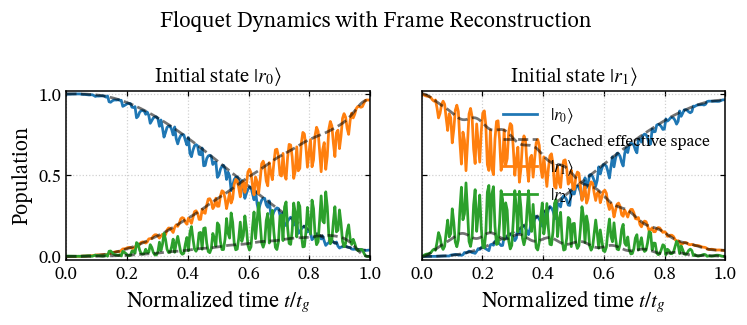

In [ ]:
time = result.tlist / result.c.tg
U_floquet_values = floquet_result["U_floquet_values"]
U_cached_values = floquet_result["U_cached_values"]
d_res = U_floquet_values.shape[1]
labels = [rf"$|r_{j}\rangle$" for j in range(d_res)]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), sharey=True, dpi=110)
for initial, ax in enumerate(axes):
    transformed = np.abs(U_floquet_values[:, :, initial])**2
    cached = np.abs(U_cached_values[:, :, initial])**2
    for state, label in enumerate(labels):
        if transformed[:, state].max() > 1e-5:
            ax.plot(time, transformed[:, state], label=label)
        if cached[:, state].max() > 1e-5:
            ax.plot(
                time, cached[:, state], "k--", alpha=0.55,
                label="Cached effective space" if state == 0 else None,
            )
    ax.set_title(f"Initial state {labels[initial]}")
    ax.set(xlabel=r"Normalized time $t/t_g$", xlim=(0, 1), ylim=(-0.02, 1.02))
    ax.grid(True, linestyle=":", alpha=0.6)

axes[0].set_ylabel("Population")
axes[1].legend(frameon=False)
fig.suptitle("Floquet Dynamics with Frame Reconstruction")
fig.tight_layout()
plt.show()


 ## 10. Direct full-system propagation



 This is another expensive stage and is therefore kept separate from its plot.

 The final computational propagator and complete population trajectories are

 stored in `direct_result`.

In [ ]:
drive = result.build_drive_signal()
tlist_direct = np.linspace(
    0.0, result.c.tg,
    max(1001, int(result.c.tg * result.c.steps_per_ns) + 1),
)
comp_states = [result.s.E_states[i] for i in result.s.comp_indices]
U_direct = np.zeros((len(comp_states), len(comp_states)), dtype=complex)

for column, psi0 in enumerate(tqdm(comp_states, desc="Direct simulation")):
    evolution = sesolve(
        [result.s.H0, [result.s.V1, drive]], psi0, tlist_direct,
        options={"nsteps": 100000},
    )
    U_direct[:, column] = [state.overlap(evolution.states[-1]) for state in comp_states]

dynamics = sesolve(
    [result.s.H0, [result.s.V1, drive]],
    result.s.E_states[result.state_0], tlist_direct,
    options={"nsteps": 100000},
)
direct_populations = np.array([
    [abs(state.overlap(psi))**2 for psi in dynamics.states]
    for state in result.s.E_states
])

direct_result = {
    "U": U_direct,
    "infidelity": infid_population(U_direct),
    "tlist": tlist_direct,
    "populations": direct_populations,
}
result.direct_result = direct_result
print(f"Direct population infidelity: {direct_result['infidelity']:.3e}")


Direct simulation:   0%|          | 0/4 [00:00<?, ?it/s]

Direct population infidelity: 3.250e-01


 ## 11. Direct-dynamics plot



 This cell only reads the stored direct-simulation result and can therefore be

 reformatted freely without solving the Schrödinger equation again.

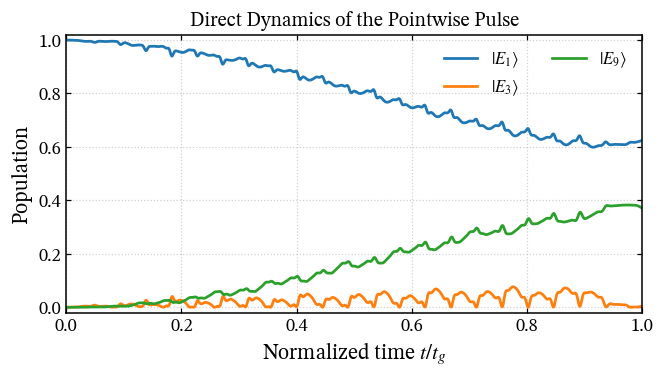

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.6), dpi=110)
for index, population in enumerate(direct_result["populations"]):
    if population.max() > 1e-4:
        ax.plot(
            direct_result["tlist"] / result.c.tg,
            population,
            label=rf"$|E_{{{index}}}\rangle$",
        )

ax.set(
    xlabel=r"Normalized time $t/t_g$",
    ylabel="Population",
    xlim=(0, 1),
    ylim=(-0.02, 1.02),
)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=False, ncol=2)
ax.set_title("Direct Dynamics of the Pointwise Pulse", fontweight="bold")
fig.tight_layout()
plt.show()


 ## 12. Summary



 The final cell collects the three central predictions without performing any

 additional propagation.

In [ ]:
# Direct numerical optimization of wd_offset, A1 scale and A2 scale.
# Each amplitude scale multiplies both quadratures of its harmonic.

from scipy.optimize import differential_evolution
from qutip import sesolve
from pulse_optimization import infid_population

if not result.c.use_second_harmonic:
    raise ValueError("This optimization requires use_second_harmonic=True.")

parameter_names = ["wd_offset", "amp1_scale", "amp2_scale"]
parameter_bounds = [
    (-0.2, 0.2),   # wd_offset
    (0.5, 1.8),    # A1 scale
    (-3.0, 3.0),   # A2 scale
]

comp_states = [result.s.E_states[i] for i in result.s.comp_indices]
tspan = np.array([0.0, result.c.tg])
objective_cache = {}

def direct_propagator(parameters):
    wd_offset, amp1_scale, amp2_scale = parameters

    def drive(t, args=None):
        wd = float(result.wd_func(t)) + wd_offset
        phi = wd * t

        q1 = (
            float(result.Ar_func(t)) * np.cos(phi)
            + float(result.Ai_func(t)) * np.sin(phi)
        )
        q2 = (
            float(result.Ar2_func(t)) * np.cos(2.0 * phi)
            + float(result.Ai2_func(t)) * np.sin(2.0 * phi)
        )
        return amp1_scale * q1 + amp2_scale * q2

    U = np.zeros((len(comp_states), len(comp_states)), dtype=complex)

    for column, psi0 in enumerate(comp_states):
        evolution = sesolve(
            [result.s.H0, [result.s.V1, drive]],
            psi0,
            tspan,
            options={"nsteps": 100000},
        )
        psi_final = evolution.states[-1]
        U[:, column] = [state.overlap(psi_final) for state in comp_states]

    return U

def iteration_callback(xk, convergence=None):
    wd_off, a1, a2 = xk
    # Berechnet den aktuellen Bestwert aus dem Cache
    current_best_key = tuple(np.round(xk, 12))
    current_cost = objective_cache.get(current_best_key, "N/A")
    
    if isinstance(current_cost, float):
        print(f"[Generation] Best Infid: {current_cost:.6e} | wd_off: {wd_off:.6f}, A1: {a1:.6f}, A2: {a2:.6f}")
    else:
        print(f"[Generation] Best Params: wd_off: {wd_off:.6f}, A1: {a1:.6f}, A2: {a2:.6f}")

def objective(parameters):
    key = tuple(np.round(parameters, 12))

    if key not in objective_cache:
        objective_cache[key] = infid_population(
            direct_propagator(parameters)
        )

    return objective_cache[key]

direct_opt = differential_evolution(
    objective,
    bounds=parameter_bounds,
    x0=np.array([0.0, 1.0, 1.0]),strategy="best1bin",popsize=6,maxiter=30,tol=1e-7,atol=1e-10,polish=True,seed=1,workers=1,updating="immediate",disp=True,
    callback=iteration_callback,
)

wd_offset_opt, amp1_scale_opt, amp2_scale_opt = direct_opt.x
U_direct_opt = direct_propagator(direct_opt.x)
I_pop_direct_opt = infid_population(U_direct_opt)

result.wd_offset_opt = wd_offset_opt
result.amp1_scale_opt = amp1_scale_opt
result.amp2_scale_opt = amp2_scale_opt
result.U_direct_opt = U_direct_opt
result.I_pop_direct_opt = I_pop_direct_opt

def optimized_drive_signal(t, args=None):
    wd = float(result.wd_func(t)) + wd_offset_opt
    phi = wd * t

    q1 = (
        float(result.Ar_func(t)) * np.cos(phi)
        + float(result.Ai_func(t)) * np.sin(phi)
    )
    q2 = (
        float(result.Ar2_func(t)) * np.cos(2.0 * phi)
        + float(result.Ai2_func(t)) * np.sin(2.0 * phi)
    )
    return amp1_scale_opt * q1 + amp2_scale_opt * q2

print("\nOptimized direct pulse")
print(f"wd_offset:  {wd_offset_opt:.12g}")
print(f"amp1_scale: {amp1_scale_opt:.12g}")
print(f"amp2_scale: {amp2_scale_opt:.12g}")
print(f"Population fidelity:   {1.0 - I_pop_direct_opt:.10f}")
print(f"Population infidelity: {I_pop_direct_opt:.3e}")

RuntimeError: The map-like callable must be of the form f(func, iterable), returning a sequence of numbers the same length as 'iterable'

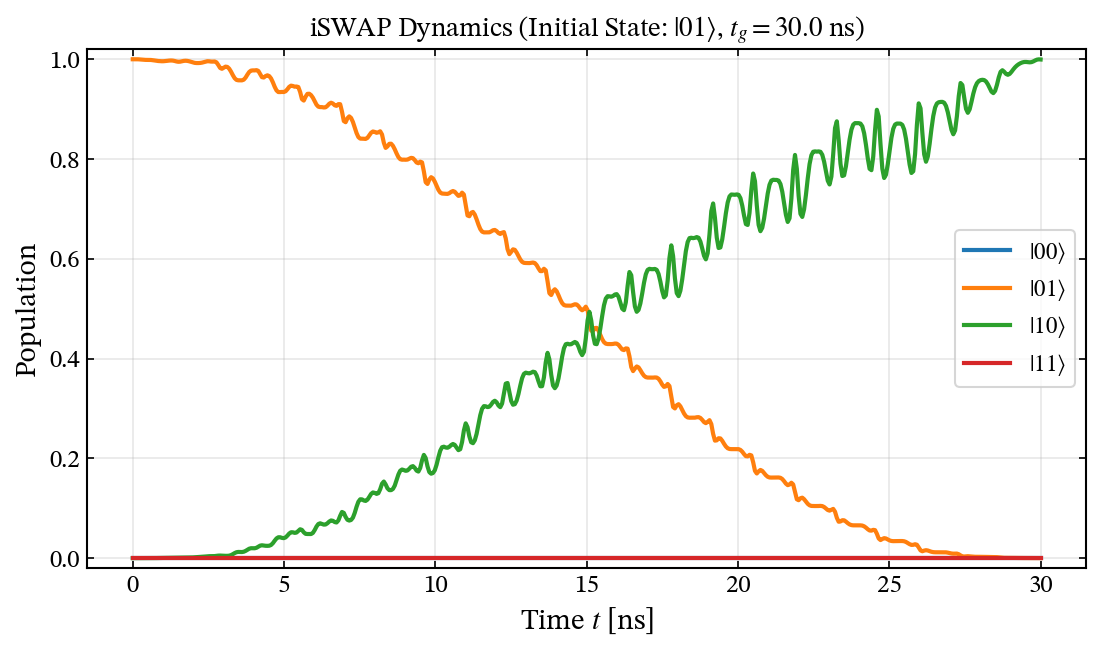

              OPTIMIZATION SUMMARY               
Gate duration (tg) : 30.0 ns
Optimal wd_offset  : -0.09992483 GHz
Optimal amp1_scale : 0.84972584
Optimal amp2_scale : 1.59155285
Final Infidelity   : 2.2424e-03
Final Fidelity     : 99.775760 %


In [ ]:
import matplotlib.pyplot as plt

# 1. Zeitgitter für Trajektorien
t_plot = np.linspace(0, result.c.tg, 500)

# 2. Startzustand auf |01> setzen (Index 1 der computational states)
init_idx = 1
psi0_plot = comp_states[init_idx]

res_plot = sesolve(
    [result.s.H0, [result.s.V1, optimized_drive_signal]],
    psi0_plot,
    t_plot,
    options={"nsteps": 100000},
)

# 3. Populationen berechnen: P_i(t) = |<psi_i | psi(t)>|^2
num_comp = len(comp_states)
pops = np.zeros((num_comp, len(t_plot)))
for idx, state in enumerate(comp_states):
    pops[idx, :] = [abs(state.overlap(psi)) ** 2 for psi in res_plot.states]

# 4. Binäre Zustands-Labels erzeugen (|00>, |01>, |10>, |11>)
bit_len = int(np.log2(num_comp)) if num_comp > 1 else 1
state_labels = [
    rf"$|{format(i, f'0{bit_len}b')}\rangle$" for i in range(num_comp)
]

# 5. Dynamics Plot
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=150)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for idx in range(num_comp):
    ax.plot(
        t_plot,
        pops[idx, :],
        label=state_labels[idx],
        color=colors[idx % len(colors)],
        lw=2.0,
    )

ax.set_xlabel(r"Time $t$ [ns]")
ax.set_ylabel("Population")
ax.set_title(
    rf"iSWAP Dynamics (Initial State: {state_labels[init_idx]}, $t_g = {result.c.tg}$ ns)"
)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="center right", frameon=True)

plt.tight_layout()
plt.show()

# 6. Summary
print("==================================================")
print("              OPTIMIZATION SUMMARY               ")
print("==================================================")
print(f"Gate duration (tg) : {result.c.tg} ns")
print(f"Optimal wd_offset  : {wd_offset_opt:.8f} GHz")
print(f"Optimal amp1_scale : {amp1_scale_opt:.8f}")
print(f"Optimal amp2_scale : {amp2_scale_opt:.8f}")
print(f"Final Infidelity   : {I_pop_direct_opt:.4e}")
print(f"Final Fidelity     : {(1.0 - I_pop_direct_opt) * 100:.6f} %")
print("==================================================")